<a href="https://colab.research.google.com/github/yamatai-wizard/GCI_Competition2/blob/test/NFL_Draft_Prediction_ipynb%E3%80%80%E5%AE%9F%E8%A1%8C%E7%89%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第2回データ分析コンペティション：NFL Draft Prediction

## 目次
1. セットアップ
2. データ読み込み
3. データの分析・EDA
4. 前処理
5. ベースラインモデル
6. 仮説と特徴量エンジニアリング
7. 提出ファイル作成
8. 今後の展望

## 1. セットアップ

In [20]:
from google.colab import drive,files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc

from xgboost import XGBClassifier

!pip install optuna
import optuna
from optuna.samplers import TPESampler

In [22]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 2. データ読み込み

In [23]:
PATH = '/content/drive/MyDrive/GCI/NFL Draft Prediction/'

train = pd.read_csv(PATH + 'train.csv')
test = pd.read_csv(PATH + 'test.csv')

## 4. 前処理

In [24]:
# 使わない列の削除
train = train.drop(columns=["Id"])
test = test.drop(columns=["Id"])

In [25]:
# prompt: 欠損値を全て-9999で埋める

train = train.fillna(-9999)
test = test.fillna(-9999)

In [26]:
train.isnull().sum()

,0
Year,0
Age,0
School,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0


In [27]:
test.isnull().sum()

,0
Year,0
Age,0
School,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0


In [28]:
# カテゴリデータをラベルエンコーディング
label_encoders = {}
for c in ["Player_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    train[c] = label_encoders[c].fit_transform(train[c].astype(str))
    test[c] = label_encoders[c].transform(test[c].astype(str))

In [29]:
# # カテゴリデータのワンホットエンコーディング
# train = pd.get_dummies(train, columns=["Player_Type", "Position_Type", "Position"], dummy_na=False, dtype=int)
# test = pd.get_dummies(test, columns=["Player_Type", "Position_Type", "Position"], dummy_na=False, dtype=int)

# # trainとtestでカラムを揃える
# train_cols = set(train.columns)
# test_cols = set(test.columns)

# missing_in_test = list(train_cols - test_cols)
# for c in missing_in_test:
#     if c != 'Drafted': # 'Drafted' はtestには存在しない
#         test[c] = 0.0

# missing_in_train = list(test_cols - train_cols)
# for c in missing_in_train:
#     train[c] = 0.0

# # カラムの順序をtrainに合わせる
# test = test[train.columns.drop('Drafted')]

In [30]:
train.head()

,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,1,offensive_lineman,10,1.0
1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,-9999.00,-9999.00,1,backs_receivers,19,1.0
2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,1,backs_receivers,19,1.0
3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,0,defensive_lineman,4,1.0
4,2016,21.0,California,1.8796,92.079251,4.64,78.74,-9999.0,281.94,7.13,4.20,1,backs_receivers,19,1.0


## 6. 仮説と特徴量エンジニアリング

In [31]:
# prompt: 交差項の作成して'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
#     'Broad_Jump', 'Agility_3cone', 'Shuttle'

import pandas as pd
# 特徴量エンジニアリング：交差項の作成
interaction_features = ['Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                        'Broad_Jump', 'Agility_3cone', 'Shuttle']

# PolynomialFeaturesを使用して交差項を生成
# degree=2で2次の項と交差項を生成、include_bias=Falseでバイアス項を含めない
poly = PolynomialFeatures(degree=2, include_bias=False)

# trainとtestの指定された特徴量に対して交差項を生成
train_interaction = poly.fit_transform(train[interaction_features])
test_interaction = poly.transform(test[interaction_features])

# 生成された交差項をDataFrameに変換
# get_feature_names_outで生成された特徴量の名前を取得
train_interaction_df = pd.DataFrame(train_interaction, columns=poly.get_feature_names_out(interaction_features))
test_interaction_df = pd.DataFrame(test_interaction, columns=poly.get_feature_names_out(interaction_features))

# 元のDataFrameから交差項のもとになった特徴量を削除
train = train.drop(columns=interaction_features)
test = test.drop(columns=interaction_features)

# 生成された交差項を元のDataFrameに追加
train = pd.concat([train.reset_index(drop=True), train_interaction_df.reset_index(drop=True)], axis=1)
test = pd.concat([test.reset_index(drop=True), test_interaction_df.reset_index(drop=True)], axis=1)

print("Train shape after adding interaction features:", train.shape)
print("Test shape after adding interaction features:", test.shape)
train.head()


Train shape after adding interaction features: (2781, 51)
Test shape after adding interaction features: (696, 50)


,Year,Age,School,Player_Type,Position_Type,Position,Drafted,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Height^2,Height Weight,Height Sprint_40yd,Height Vertical_Jump,Height Bench_Press_Reps,Height Broad_Jump,Height Agility_3cone,Height Shuttle,Weight^2,Weight Sprint_40yd,Weight Vertical_Jump,Weight Bench_Press_Reps,Weight Broad_Jump,Weight Agility_3cone,Weight Shuttle,Sprint_40yd^2,Sprint_40yd Vertical_Jump,Sprint_40yd Bench_Press_Reps,Sprint_40yd Broad_Jump,Sprint_40yd Agility_3cone,Sprint_40yd Shuttle,Vertical_Jump^2,Vertical_Jump Bench_Press_Reps,Vertical_Jump Broad_Jump,Vertical_Jump Agility_3cone,Vertical_Jump Shuttle,Bench_Press_Reps^2,Bench_Press_Reps Broad_Jump,Bench_Press_Reps Agility_3cone,Bench_Press_Reps Shuttle,Broad_Jump^2,Broad_Jump Agility_3cone,Broad_Jump Shuttle,Agility_3cone^2,Agility_3cone Shuttle,Shuttle^2
0,2011,21.0,Lehigh,1,offensive_lineman,10,1.0,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,3.629025,267.004881,10.267950,113.709450,55.2450,479.031300,15.068550,9.410700,19644.837458,755.462628,8366.152925,4064.641227,35244.644237,1108.665935,692.390609,29.0521,321.7291,156.31,1355.3694,42.6349,26.6266,3562.8961,1731.01,15009.6474,4.721479e+02,2.948686e+02,841.0,7292.34,229.39,143.26,63232.1316,1.989049e+03,1.242212e+03,6.256810e+01,3.907540e+01,2.440360e+01
1,2011,24.0,Abilene Christian,1,backs_receivers,19,1.0,1.8288,87.089735,4.31,101.60,16.0,332.74,-9999.00,-9999.00,3.344509,159.269707,7.882128,185.806080,29.2608,608.514912,-18286.171200,-18286.171200,7584.621949,375.356758,8848.317080,1393.435761,28978.238437,-870810.260665,-870810.260665,18.5761,437.8960,68.96,1434.1094,-43095.6900,-43095.6900,10322.5600,1625.60,33806.3840,-1.015898e+06,-1.015898e+06,256.0,5323.84,-159984.00,-159984.00,110715.9076,-3.327067e+06,-3.327067e+06,9.998000e+07,9.998000e+07,9.998000e+07
2,2018,21.0,Colorado St.,1,backs_receivers,19,1.0,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,3.438058,172.415449,8.362442,169.548048,18.5420,574.579496,12.886690,8.102854,8646.477252,419.368826,8502.679694,929.864359,28814.636741,646.255729,406.350725,20.3401,412.3944,45.10,1397.5588,31.3445,19.7087,8361.2736,914.40,28335.4272,6.355080e+02,3.995928e+02,100.0,3098.80,69.50,43.70,96025.6144,2.153666e+03,1.354176e+03,4.830250e+01,3.037150e+01,1.909690e+01
3,2010,21.0,East Carolina,0,defensive_lineman,4,1.0,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,3.726444,287.201625,9.825736,147.096480,75.2856,490.321600,15.674848,9.092184,22134.981777,757.281534,11336.906262,5802.353599,37789.687540,1208.079775,700.745781,25.9081,387.8580,198.51,1292.8600,41.3308,23.9739,5806.4400,2971.80,19354.8000,6.187440e+02,3.589020e+02,1521.0,9906.00,316.68,183.69,64516.0000,2.062480e+03,1.196340e+03,6.593440e+01,3.824520e+01,2.218410e+01
4,2016,21.0,California,1,backs_receivers,19,1.0,1.8796,92.079251,4.64,78.74,-9999.0,281.94,7.13,4.20,3.532896,173.072160,8.721344,147.999704,-18794.1204,529.934424,13.401548,7.894320,8478.588485,427.247725,7250.320232,-920700.431849,25960.824058,656.525060,386.732855,21.5296,365.3536,-46395.36,1308.2016,33.0832,19.4880,6199.9876,-787321.26,22199.9556,5.614162e+02,3.307080e+02,99980001.0,-2819118.06,-71292.87,-41995.80,79490.1636,2.010232e+03,1.184148e+03,5.083690e+01,2.994600e+01,1.764000e+01


In [32]:
for df in [train, test]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

In [33]:
# prompt: School列をターゲットエンコーディング。ただし、そのSchoolに属する人数が10人以下の場合は欠損値にする。

import numpy as np
# School列のターゲットエンコーディング
# ターゲットエンコーディング関数
def target_encode_school(train_df, test_df, target_col='Drafted', smooth=1):
    # TrainデータでSchoolごとのターゲット平均を計算
    school_means = train_df.groupby('School')[target_col].mean()

    # Schoolごとのカウントを計算
    school_counts = train_df.groupby('School')[target_col].count()

    # カウントが10以下のSchoolのターゲット平均をNaNに設定
    small_schools = school_counts[school_counts <= 10].index
    school_means[small_schools] = np.nan

    # グローバルなターゲット平均を計算 (NaNを除外したTrainデータ全体)
    global_mean = train_df[target_col].mean()

    # エンコーディングを適用
    train_encoded = train_df['School'].map(school_means)
    test_encoded = test_df['School'].map(school_means)

    # 欠損値をグローバル平均で埋める
    train_encoded = train_encoded.fillna(global_mean)
    test_encoded = test_encoded.fillna(global_mean)

    return train_encoded, test_encoded

# School列のターゲットエンコーディングを適用
train['School_Encoded'], test['School_Encoded'] = target_encode_school(train, test)

# 元のSchool列は不要なので削除
train = train.drop(columns=['School'])
test = test.drop(columns=['School'])

print("Train shape after School encoding:", train.shape)
print("Test shape after School encoding:", test.shape)
train.head()

Train shape after School encoding: (2781, 52)
Test shape after School encoding: (696, 51)


,Year,Age,Player_Type,Position_Type,Position,Drafted,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Height^2,Height Weight,Height Sprint_40yd,Height Vertical_Jump,Height Bench_Press_Reps,Height Broad_Jump,Height Agility_3cone,Height Shuttle,Weight^2,Weight Sprint_40yd,Weight Vertical_Jump,Weight Bench_Press_Reps,Weight Broad_Jump,Weight Agility_3cone,Weight Shuttle,Sprint_40yd^2,Sprint_40yd Vertical_Jump,Sprint_40yd Bench_Press_Reps,Sprint_40yd Broad_Jump,Sprint_40yd Agility_3cone,Sprint_40yd Shuttle,Vertical_Jump^2,Vertical_Jump Bench_Press_Reps,Vertical_Jump Broad_Jump,Vertical_Jump Agility_3cone,Vertical_Jump Shuttle,Bench_Press_Reps^2,Bench_Press_Reps Broad_Jump,Bench_Press_Reps Agility_3cone,Bench_Press_Reps Shuttle,Broad_Jump^2,Broad_Jump Agility_3cone,Broad_Jump Shuttle,Agility_3cone^2,Agility_3cone Shuttle,Shuttle^2,BMI,School_Encoded
0,2011,21.0,1,offensive_lineman,10,1.0,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,3.629025,267.004881,10.267950,113.709450,55.2450,479.031300,15.068550,9.410700,19644.837458,755.462628,8366.152925,4064.641227,35244.644237,1108.665935,692.390609,29.0521,321.7291,156.31,1355.3694,42.6349,26.6266,3562.8961,1731.01,15009.6474,4.721479e+02,2.948686e+02,841.0,7292.34,229.39,143.26,63232.1316,1.989049e+03,1.242212e+03,6.256810e+01,3.907540e+01,2.440360e+01,38.621956,0.648328
1,2011,24.0,1,backs_receivers,19,1.0,1.8288,87.089735,4.31,101.60,16.0,332.74,-9999.00,-9999.00,3.344509,159.269707,7.882128,185.806080,29.2608,608.514912,-18286.171200,-18286.171200,7584.621949,375.356758,8848.317080,1393.435761,28978.238437,-870810.260665,-870810.260665,18.5761,437.8960,68.96,1434.1094,-43095.6900,-43095.6900,10322.5600,1625.60,33806.3840,-1.015898e+06,-1.015898e+06,256.0,5323.84,-159984.00,-159984.00,110715.9076,-3.327067e+06,-3.327067e+06,9.998000e+07,9.998000e+07,9.998000e+07,26.039614,0.648328
2,2018,21.0,1,backs_receivers,19,1.0,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,3.438058,172.415449,8.362442,169.548048,18.5420,574.579496,12.886690,8.102854,8646.477252,419.368826,8502.679694,929.864359,28814.636741,646.255729,406.350725,20.3401,412.3944,45.10,1397.5588,31.3445,19.7087,8361.2736,914.40,28335.4272,6.355080e+02,3.995928e+02,100.0,3098.80,69.50,43.70,96025.6144,2.153666e+03,1.354176e+03,4.830250e+01,3.037150e+01,1.909690e+01,27.046212,0.461538
3,2010,21.0,0,defensive_lineman,4,1.0,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,3.726444,287.201625,9.825736,147.096480,75.2856,490.321600,15.674848,9.092184,22134.981777,757.281534,11336.906262,5802.353599,37789.687540,1208.079775,700.745781,25.9081,387.8580,198.51,1292.8600,41.3308,23.9739,5806.4400,2971.80,19354.8000,6.187440e+02,3.589020e+02,1521.0,9906.00,316.68,183.69,64516.0000,2.062480e+03,1.196340e+03,6.593440e+01,3.824520e+01,2.218410e+01,39.925004,0.500000
4,2016,21.0,1,backs_receivers,19,1.0,1.8796,92.079251,4.64,78.74,-9999.0,281.94,7.13,4.20,3.532896,173.072160,8.721344,147.999704,-18794.1204,529.934424,13.401548,7.894320,8478.588485,427.247725,7250.320232,-920700.431849,25960.824058,656.525060,386.732855,21.5296,365.3536,-46395.36,1308.2016,33.0832,19.4880,6199.9876,-787321.26,22199.9556,5.614162e+02,3.307080e+02,99980001.0,-2819118.06,-71292.87,-41995.80,79490.1636,2.010232e+03,1.184148e+03,5.083690e+01,2.994600e+01,1.764000e+01,26.063390,0.741935


In [34]:
def objective(trial, X, y):
    """Optunaの目的関数"""
    # グループによってはデータが少なく、クラスが1種類しかない場合があるためチェック
    if len(y.unique()) < 2:
        return 0.0  # AUCが計算できないため、低いスコアを返す

    params = {
        'objective': 'binary:logistic',
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'verbosity': 0
    }
    model = XGBClassifier(**params)

    # 層化K-Foldで交差検証
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_valid)[:, 1]
        scores.append(roc_auc_score(y_valid, y_pred_proba))

    return np.mean(scores)

In [35]:
# prompt: 1個上のセルのコードでやってることは変えないで、後でそれぞれのPlayer_TypeごとのモデルでのAUCカーブの描写と特徴量重要度を知りたいから、optimized_modelとか必要なものをあとから使えるようにしたい。

# Store optimized models and relevant data for later analysis
optimized_models = {}
feature_importances = {}
roc_curve_data = {} # Store fpr, tpr, and auc for plotting

# Position_Typeごとにモデルを学習・評価
position_types = train['Position_Type'].unique()
final_test_predictions = pd.Series(dtype=float)

for pos_type in position_types:
    print(f"\n{'='*20} Processing Position_Type: {pos_type} {'='*20}")

    # 1. Position_Typeでデータをフィルタリング
    train_group = train[train['Position_Type'] == pos_type].copy()
    test_group = test[test['Position_Type'] == pos_type].copy()

    # このグループのテストデータが存在しない場合はスキップ
    if test_group.empty:
        print(f"No test data for {pos_type}. Skipping.")
        continue

    # 2. 特徴量とターゲットを準備
    # 'Position_Type'はモデルの学習には不要なため除外
    X = train_group.drop(columns=['Drafted', 'Position_Type'])
    y = train_group['Drafted']
    X_test = test_group.drop(columns=['Position_Type'])

    # グループによっては訓練データが少なく、クラスが1種類しかない場合があるためチェック
    if len(y.unique()) < 2:
        print(f"Train data for {pos_type} has only one class. Cannot train model. Skipping.")
        continue

    # 3. Optunaでハイパーパラメータ最適化
    sampler = optuna.samplers.TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    # objective関数を呼び出す際にXとyを渡すように変更
    study.optimize(lambda trial: objective(trial, X, y), n_trials=50) # n_trialsは必要に応じて調整

    best_params = study.best_params
    print(f"\nBest params for {pos_type}: {best_params}")
    print(f"Best AUC for {pos_type}: {study.best_value:.4f}\n")

    # 4. 最適化されたモデルで評価と予測
    optimized_model = XGBClassifier(**best_params, random_state=42,
                                        use_label_encoder=False, eval_metric='logloss', verbosity=0)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []
    test_pred_probas = []

    # For ROC curve plotting and feature importance, we will train on the full group data
    # after finding the best parameters. K-fold is used for evaluation.
    # Train the final optimized model on the entire training data for this group
    optimized_model.fit(X, y)

    # Store the trained model
    optimized_models[pos_type] = optimized_model

    # Store feature importance
    feature_importances[pos_type] = pd.Series(optimized_model.feature_importances_, index=X.columns).sort_values(ascending=False)

    # Calculate and store ROC curve data on a held-out fold or the full training data (for visualization purposes)
    # A better approach for robust ROC would be averaging over folds, but for simplicity of saving data:
    # Let's use the prediction on the full training data X for plotting purposes.
    # Note: This ROC curve is on the training data itself, not a valid OOF validation set.
    # For a proper ROC curve, you'd typically aggregate predictions from OOF validation sets.
    # As requested, we'll save data derived *from* the optimized model after training on the full group data.

    # Predict probabilities on the training data for ROC curve plotting
    y_train_pred_proba = optimized_model.predict_proba(X)[:, 1]
    fpr, tpr, thresholds = roc_curve(y, y_train_pred_proba)
    roc_auc = auc(fpr, tpr)

    roc_curve_data[pos_type] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}


    # Predict probabilities on the test data for submission (using the model trained on full group data)
    test_pred_proba = optimized_model.predict_proba(X_test)[:, 1]
    group_predictions = pd.Series(test_pred_proba, index=test_group.index)
    final_test_predictions = pd.concat([final_test_predictions, group_predictions])


    # Optional: Re-calculate AUC using K-Fold splits just for reporting average AUC during training phase
    # This part is for reporting, the saved model is trained on the full group data.
    kfold_auc_scores = []
    kfold_test_pred_probas = []
    skf_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for fold, (train_idx_kfold, valid_idx_kfold) in enumerate(skf_eval.split(X, y)):
        X_train_kfold, X_valid_kfold = X.iloc[train_idx_kfold], X.iloc[valid_idx_kfold]
        y_train_kfold, y_valid_kfold = y.iloc[train_idx_kfold], y.iloc[valid_idx_kfold]

        # Train a model instance for this fold for AUC calculation
        fold_model = XGBClassifier(**best_params, random_state=42,
                                   use_label_encoder=False, eval_metric='logloss', verbosity=0)
        fold_model.fit(X_train_kfold, y_train_kfold)

        y_valid_pred_proba_kfold = fold_model.predict_proba(X_valid_kfold)[:, 1]
        kfold_auc_scores.append(roc_auc_score(y_valid_kfold, y_valid_pred_proba_kfold))

        # Optionally, average predictions over folds for test data as well (though the final submission uses the model trained on full data)
        # kfold_test_pred_probas.append(fold_model.predict_proba(X_test)[:, 1])

    mean_auc_kfold = np.mean(kfold_auc_scores)
    print(f"Average Validation AUC (K-Fold) for {pos_type}: {mean_auc_kfold:.4f}")


# --- 最終的なテストデータの予測結果 ---
print(f"\n{'='*25} Final Predictions {'='*25}")
# 元のテストデータの順番にソート
final_test_predictions = final_test_predictions.sort_index()
print(final_test_predictions.head())

[I 2025-07-03 13:17:26,184] A new study created in memory with name: no-name-d3ee7325-2910-4d7e-9a4d-a3d09282f1af



==================== Processing Position_Type: offensive_lineman ====================


[I 2025-07-03 13:17:39,175] Trial 0 finished with value: 0.7804789619709201 and parameters: {'n_estimators': 218, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.15599452033620265, 'min_child_weight': 1}. Best is trial 0 with value: 0.7804789619709201.
[I 2025-07-03 13:17:48,468] Trial 1 finished with value: 0.774640882825375 and parameters: {'n_estimators': 440, 'max_depth': 7, 'learning_rate': 0.11114989443094977, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'gamma': 0.8324426408004217, 'min_child_weight': 3}. Best is trial 0 with value: 0.7804789619709201.
[I 2025-07-03 13:17:49,302] Trial 2 finished with value: 0.7854887317381842 and parameters: {'n_estimators': 132, 'max_depth': 4, 'learning_rate': 0.028145092716060652, 'subsample': 0.762378215816119, 'colsample_bytree': 0.7159725093210578, 'gamma': 0.2912291401980419, 'min_child_weight': 7}. Best is trial 2 with v


Best params for offensive_lineman: {'n_estimators': 233, 'max_depth': 9, 'learning_rate': 0.021147822835184477, 'subsample': 0.6672668838948195, 'colsample_bytree': 0.8448372126058836, 'gamma': 0.766148653309318, 'min_child_weight': 4}
Best AUC for offensive_lineman: 0.7976



/tmp/ipython-input-35-1928878599.py:85: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  final_test_predictions = pd.concat([final_test_predictions, group_predictions])
[I 2025-07-03 13:19:25,167] A new study created in memory with name: no-name-8d7455eb-985c-4e33-a91a-0b10765583e0


...


Best params for defensive_back: {'n_estimators': 354, 'max_depth': 8, 'learning_rate': 0.03881774199823307, 'subsample': 0.9355757720920582, 'colsample_bytree': 0.5799116898506457, 'gamma': 0.7487607527813893, 'min_child_weight': 2}
Best AUC for defensive_back: 0.8819



[I 2025-07-03 13:25:49,862] A new study created in memory with name: no-name-1eab5173-2dc6-4fb5-af12-096aaef4a3f1


Average Validation AUC (K-Fold) for defensive_back: 0.8819

==================== Processing Position_Type: kicking_specialist ====================


[I 2025-07-03 13:25:50,371] Trial 0 finished with value: 0.7644230769230769 and parameters: {'n_estimators': 218, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.15599452033620265, 'min_child_weight': 1}. Best is trial 0 with value: 0.7644230769230769.
[I 2025-07-03 13:25:51,080] Trial 1 finished with value: 0.7997435897435897 and parameters: {'n_estimators': 440, 'max_depth': 7, 'learning_rate': 0.11114989443094977, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'gamma': 0.8324426408004217, 'min_child_weight': 3}. Best is trial 1 with value: 0.7997435897435897.
[I 2025-07-03 13:25:51,425] Trial 2 finished with value: 0.5 and parameters: {'n_estimators': 132, 'max_depth': 4, 'learning_rate': 0.028145092716060652, 'subsample': 0.762378215816119, 'colsample_bytree': 0.7159725093210578, 'gamma': 0.2912291401980419, 'min_child_weight': 7}. Best is trial 1 with value: 0.799743


Best params for kicking_specialist: {'n_estimators': 184, 'max_depth': 6, 'learning_rate': 0.017995434278018654, 'subsample': 0.7409692480440346, 'colsample_bytree': 0.7525908622006415, 'gamma': 0.14049393618643463, 'min_child_weight': 2}
Best AUC for kicking_specialist: 0.8361

Average Validation AUC (K-Fold) for kicking_specialist: 0.8361

==================== Processing Position_Type: other_special ====================
No test data for other_special. Skipping.

========================= Final Predictions =========================
0    0.609955
1    0.974517
2    0.893862
3    0.909295
4    0.826880
dtype: float32



========================= Plotting Top Feature Importances =========================


/tmp/ipython-input-39-3710442201.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


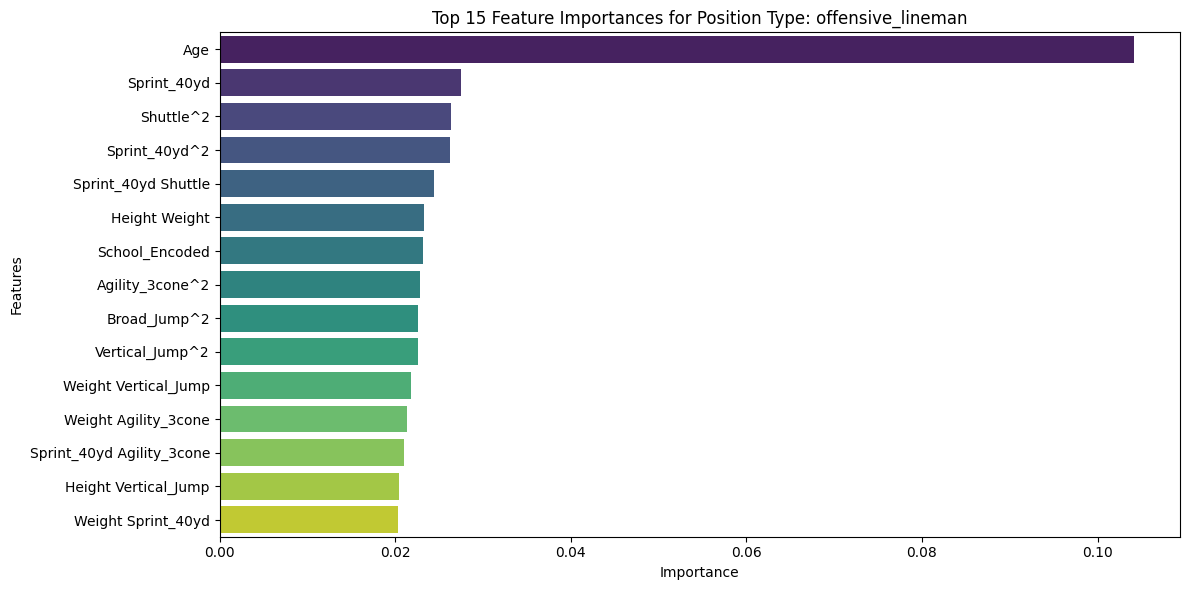

/tmp/ipython-input-39-3710442201.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


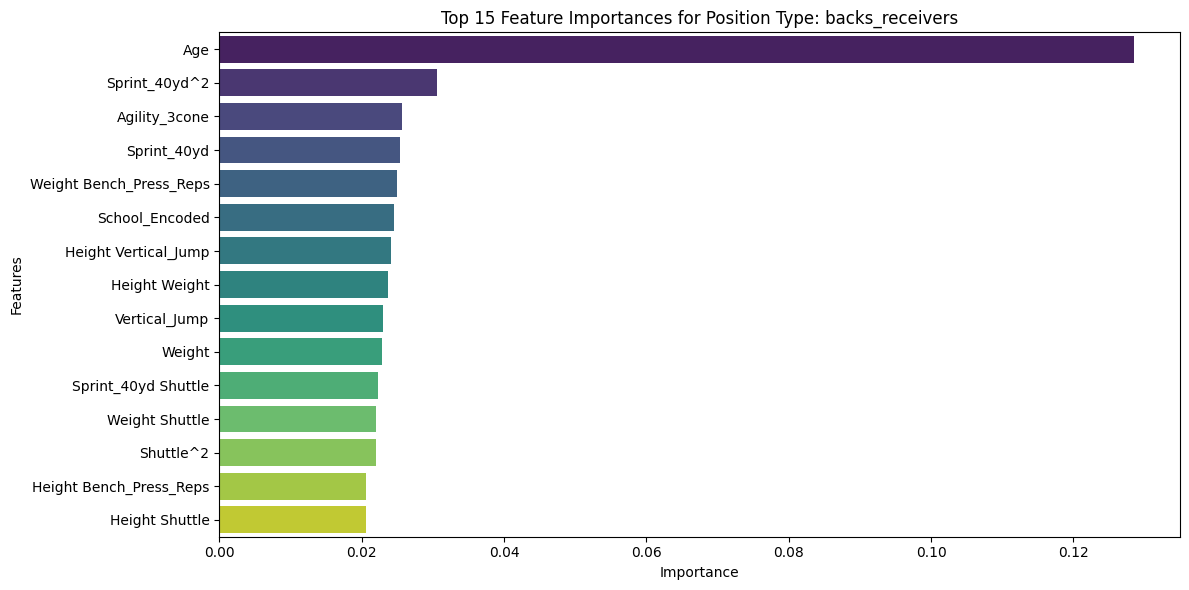

/tmp/ipython-input-39-3710442201.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


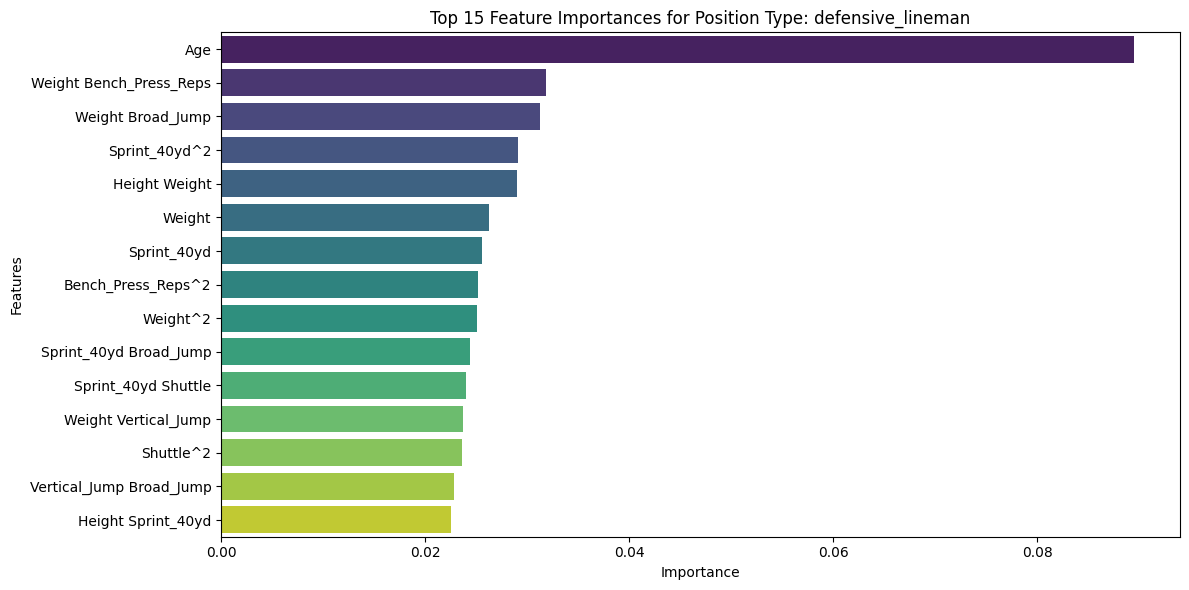

/tmp/ipython-input-39-3710442201.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


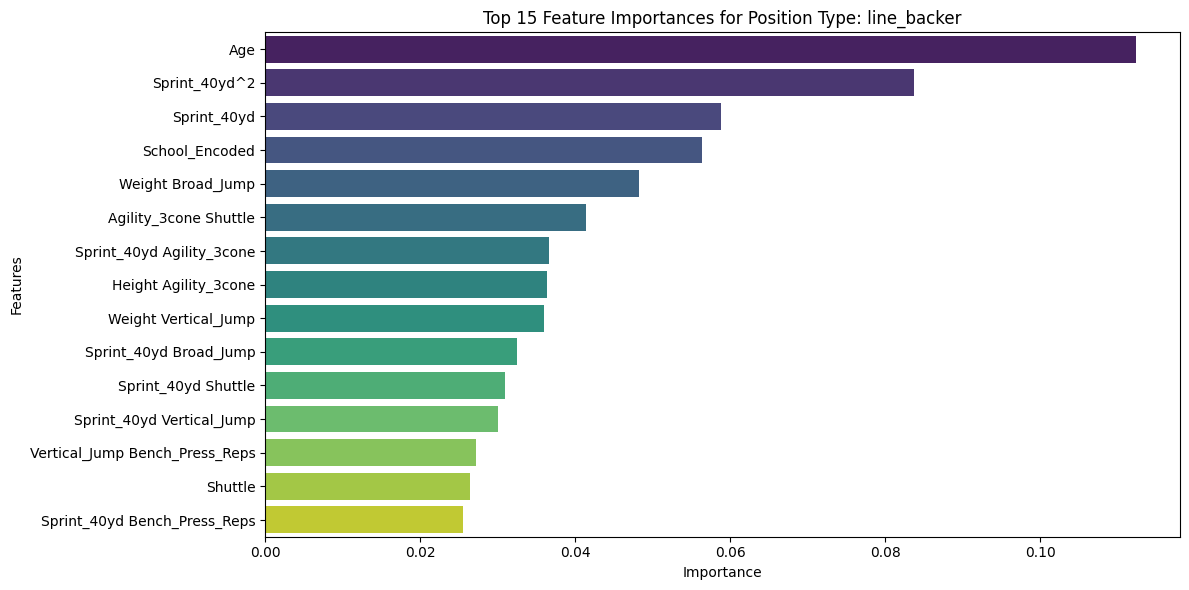

/tmp/ipython-input-39-3710442201.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


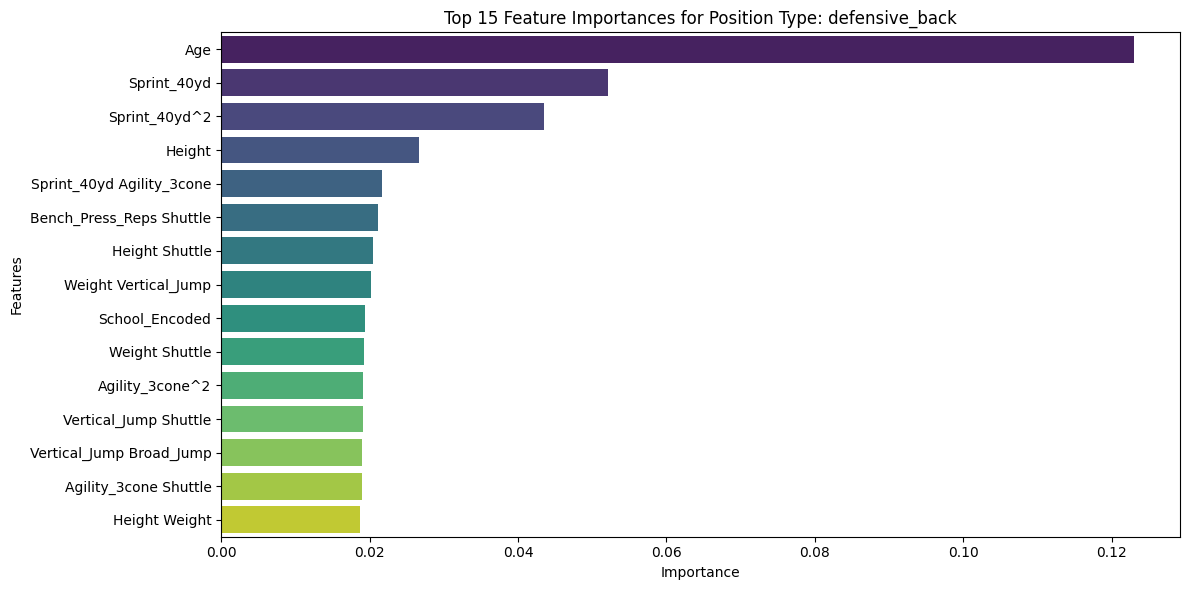

/tmp/ipython-input-39-3710442201.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


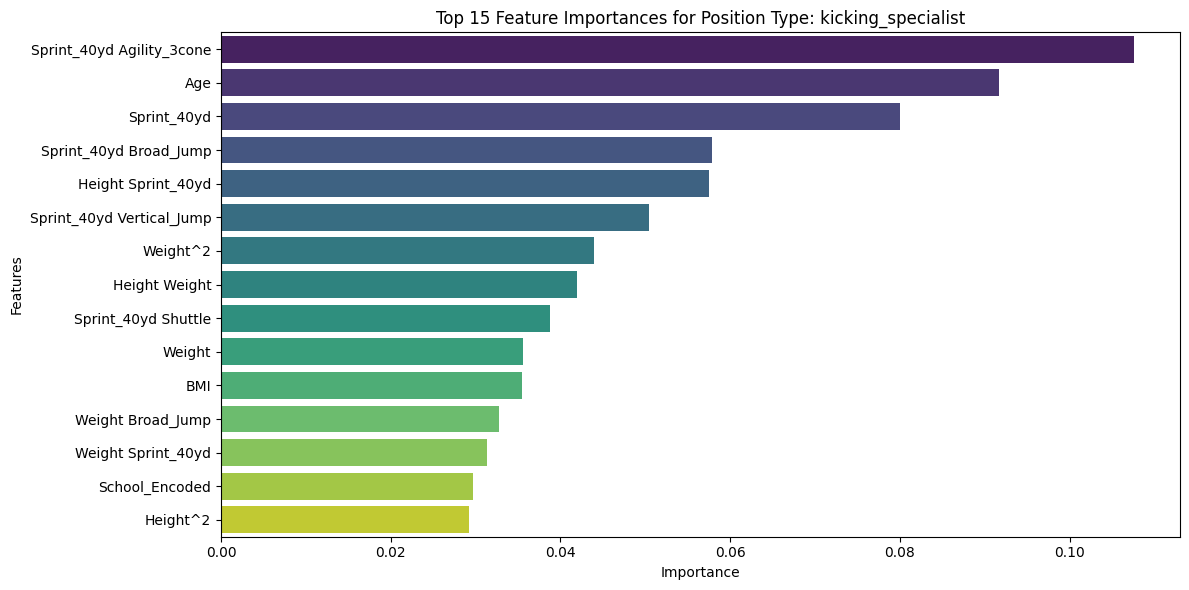

In [39]:
# prompt: 各Position_Typeごとに重要な特徴量を知りたい。モデルはもう学習済みだからそれを使って。グラフで可視化もして

import matplotlib.pyplot as plt
# 各Position_Typeごとに上位の特徴量を可視化
print(f"\n{'='*25} Plotting Top Feature Importances {'='*25}")

for pos_type, importance_series in feature_importances.items():
    plt.figure(figsize=(12, 6))
    # 上位15個の特徴量をプロット
    top_features = importance_series.head(15)
    sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
    plt.title(f'Top 15 Feature Importances for Position Type: {pos_type}')
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()


## 7. 提出ファイル作成

In [40]:
submission = pd.read_csv(PATH + 'sample_submission.csv')
submission["Drafted"] = final_test_predictions
submission.to_csv(PATH + 'submission.csv', index=False)

files.download(PATH + 'submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. 今後の展望

　本ノートブックでは、データの前処理から特徴量エンジニアリング、モデル構築、評価まで、ベースラインモデルの構築を行いました。

　今後はこのベースラインを土台として、さらに高度な特徴量の工夫やアルゴリズムの改善などによって精度向上を目指していくことができます。例えば、以下のような工夫が考えられます。

- カテゴリデータのエンコーディング手法の変更
- 欠損値の補完手法の変更
- 別のモデルの検討
- モデルのハイパーパラメータ調整
- 特徴量エンジニアリング


　高スコア獲得を目指して、頑張りましょう！